## Imports

In [98]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from scipy.stats import norm
import requests
import os
import plotly.graph_objects as go
import dataframe_image as dfi
import time
from bs4 import BeautifulSoup # library to parse HTML documents
from collections import Counter
import re
import pyfolio as pf
import itertools
from itertools import chain
import matplotlib.ticker as mtick
# import networkx as nx
from upsetplot import from_contents
from upsetplot import plot
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from matplotlib.dates import DateFormatter, DayLocator
import imgkit
%matplotlib inline

import cvxpy as cp
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

import openai

# import cplex

import cvxpy as cp
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# from __future__ import print_function

from venn import venn
from matplotlib_venn import venn3
from matplotlib_venn import venn2_unweighted, venn3_unweighted

In [57]:
sectors = ['energy', 'materials', 'industrials', 'consumer_discretionary',\
           'consumer_staples', 'health_care', 'financials', 'information_technology',\
           'communication_services', 'utilities', 'real_estate', 'S&P500']

## Venn diagrams (see picked stocks similarity)

In [58]:
def plot_venn(sector_name):
    csv_path_3 = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    csv_path_4 = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    csv_path_4preview = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    # csv_path_bard = f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'

    portfolio_3 = set(pd.read_csv(csv_path_3)['Stock'])
    portfolio_4 = set(pd.read_csv(csv_path_4)['Stock'])
    portfolio_4preview = set(pd.read_csv(csv_path_4preview)['Stock'])
    # portfolio_bard = set(pd.read_csv(csv_path_bard)['Stock'])

    data_venn = {
    "GPT3": set(portfolio_3),
    "GPT4": set(portfolio_4),
    "GPT4_preview": set(portfolio_4preview)
    }

    venn_diagram = venn(data_venn)
    venn_diagram.set_title(f'Portfolio similarities for sector {sector_name}')

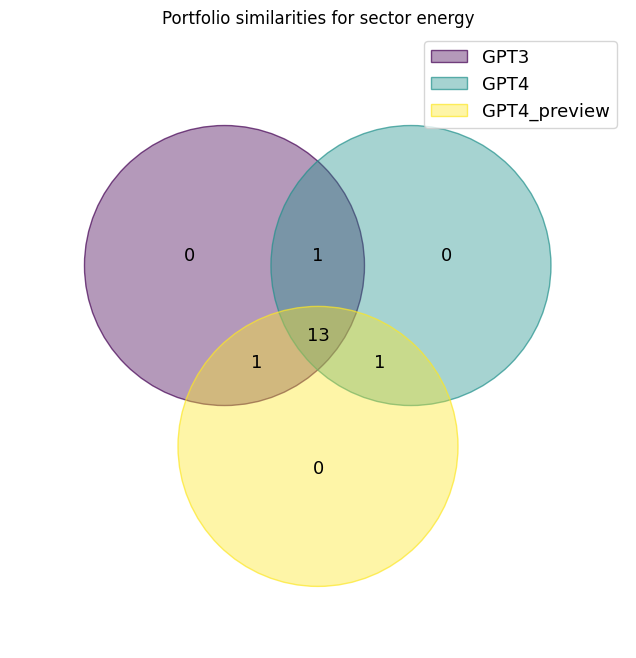

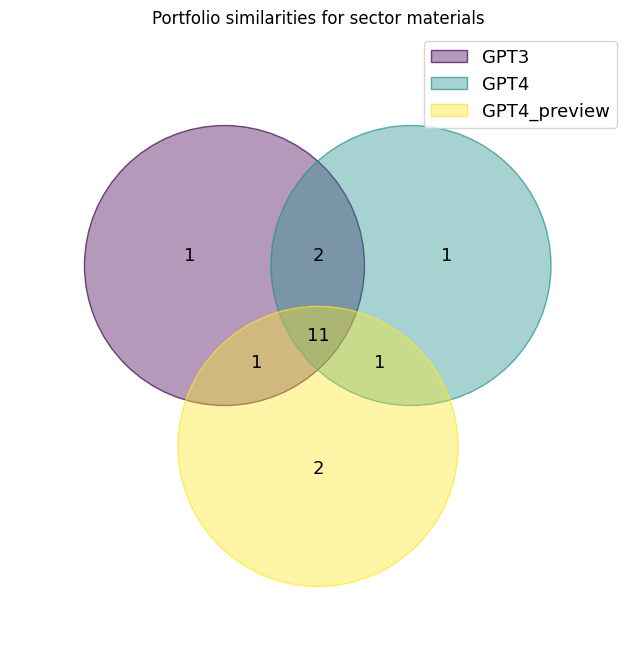

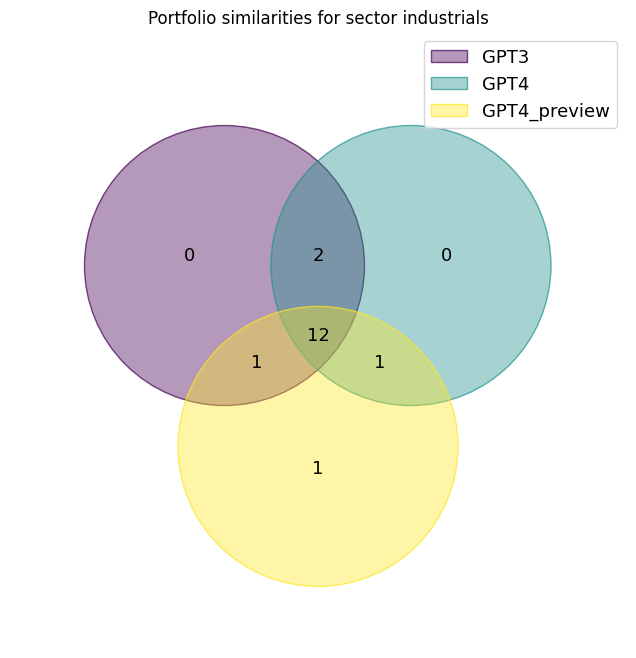

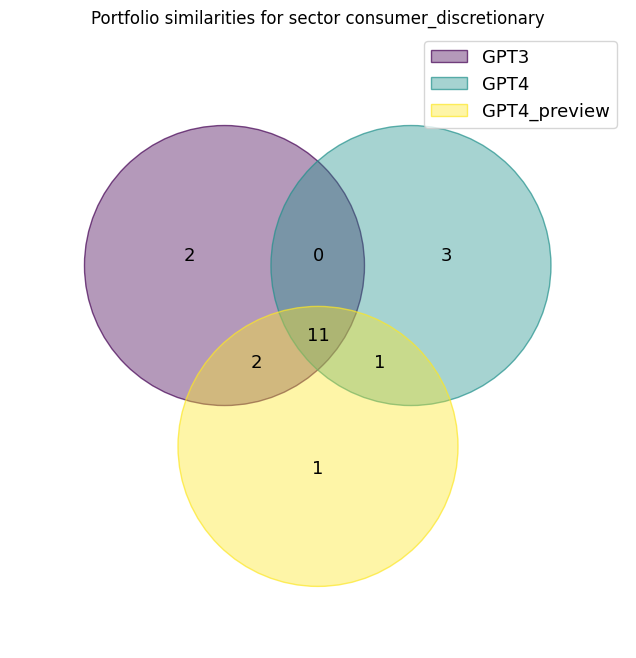

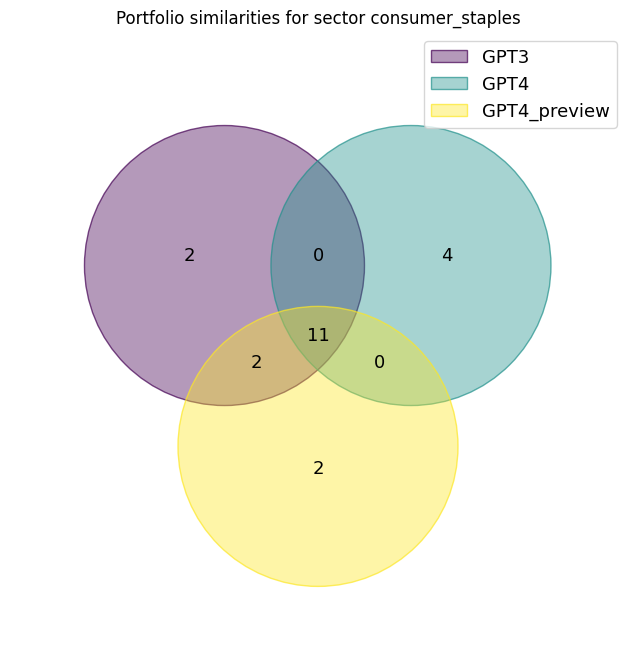

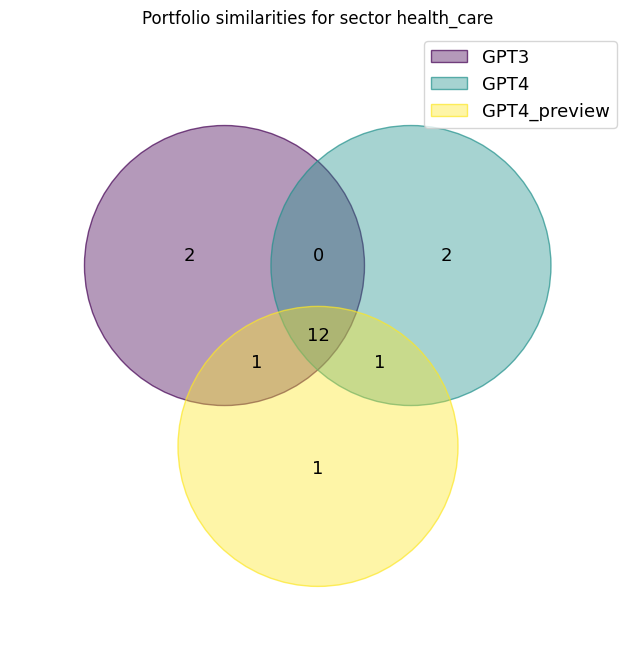

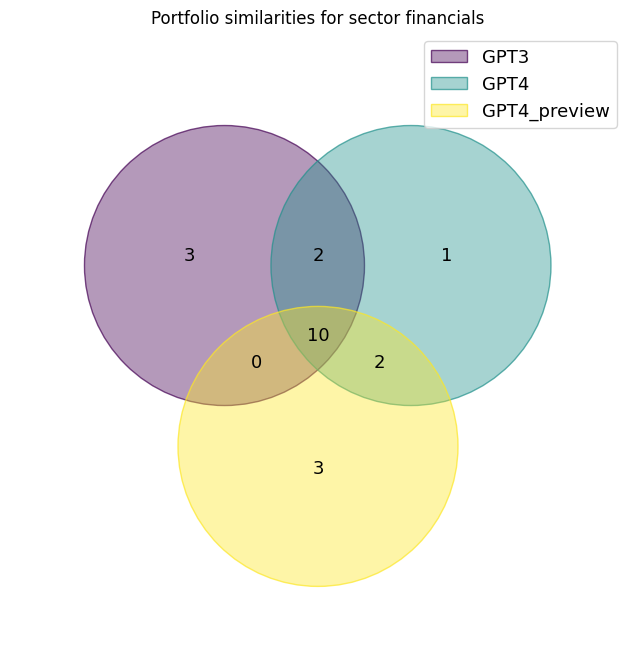

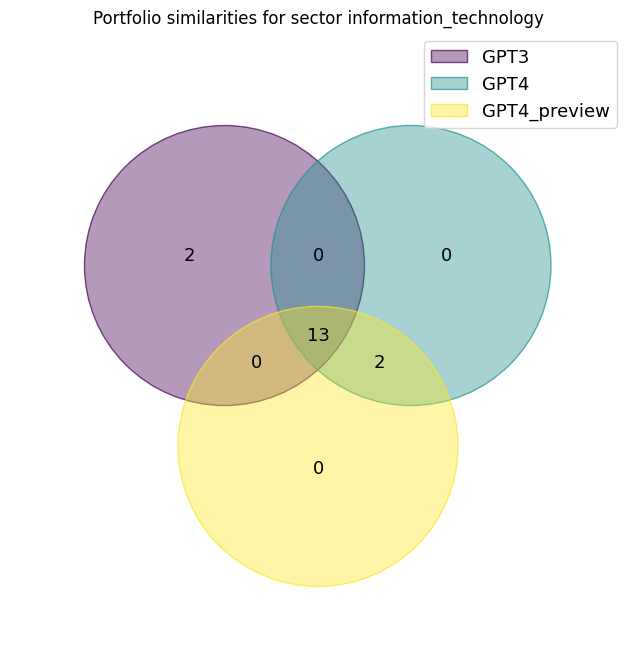

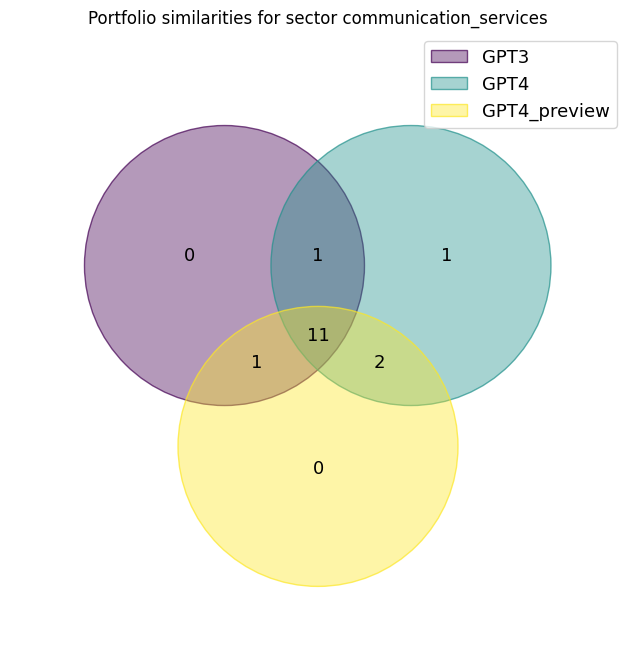

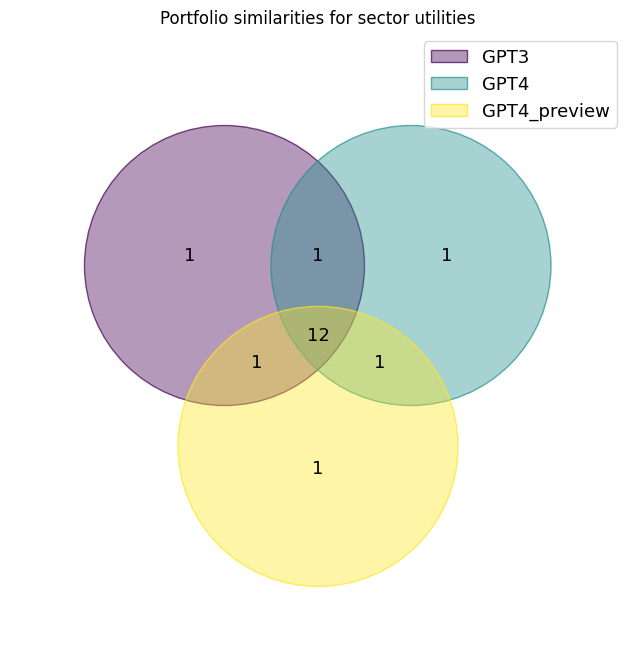

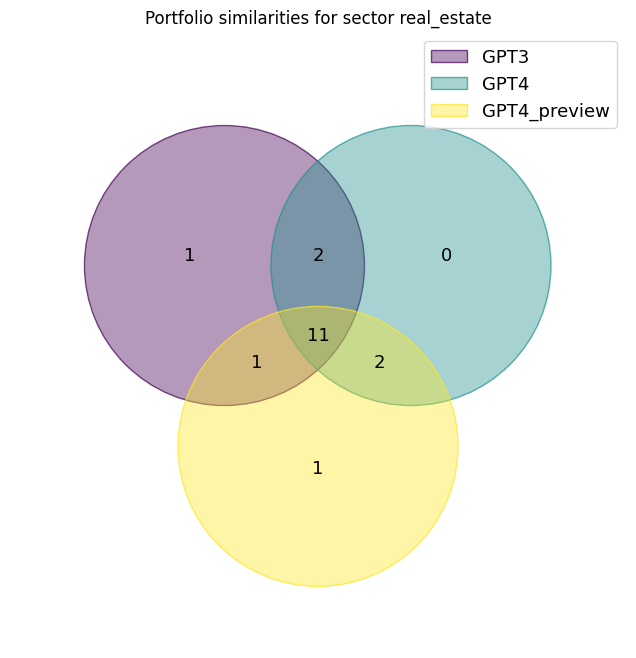

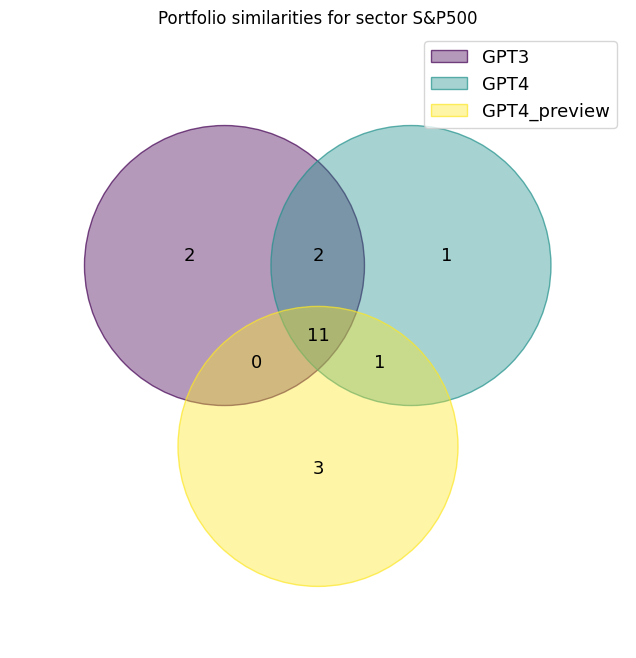

In [59]:
for sector_name in sectors:
    plot_venn(sector_name)

In [105]:
def plot_venn_with_text(sector_name):
    csv_path_3 = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    csv_path_4 = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    csv_path_4preview = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'
    # csv_path_bard = f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'

    portfolio_3 = set(pd.read_csv(csv_path_3)['Stock'])
    portfolio_4 = set(pd.read_csv(csv_path_4)['Stock'])
    portfolio_4preview = set(pd.read_csv(csv_path_4preview)['Stock'])
    # portfolio_bard = set(pd.read_csv(csv_path_bard)['Stock'])

    vennd = venn3_unweighted([portfolio_3, portfolio_4, portfolio_4preview], ('GPT3', 'GPT4', 'GPT4_preview'), alpha=0.3)

    vennd.get_label_by_id('100').set_text('\n'.join(portfolio_3-portfolio_4-portfolio_4preview))
    vennd.get_label_by_id('110').set_text('\n'.join(portfolio_3&portfolio_4-portfolio_4preview))
    vennd.get_label_by_id('010').set_text('\n'.join(portfolio_4-portfolio_4preview-portfolio_3))
    vennd.get_label_by_id('101').set_text('\n'.join(portfolio_3&portfolio_4preview-portfolio_4))
    # vennd.get_label_by_id('111').set_text('\n'.join(portfolio_3&portfolio_4&portfolio_4preview))
    vennd.get_label_by_id('011').set_text('\n'.join(portfolio_4&portfolio_4preview-portfolio_3))
    vennd.get_label_by_id('001').set_text('\n'.join(portfolio_4preview-portfolio_4-portfolio_3))

    plt.title(f'Portfolio similarities for sector {sector_name}')
    plt.figure(figsize=(5,5))

    for text in vennd.set_labels: text.set_fontsize(10)
    for text in vennd.subset_labels: text.set_fontsize(8)

    plt.show()
 

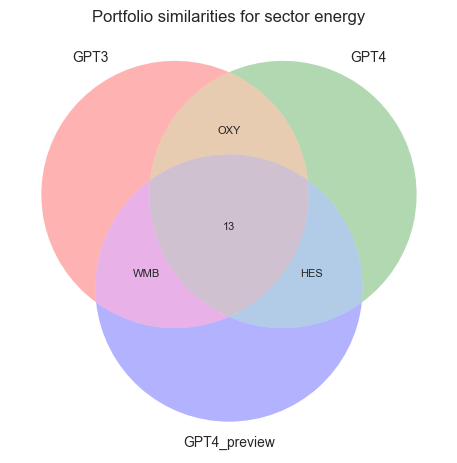

<Figure size 500x500 with 0 Axes>

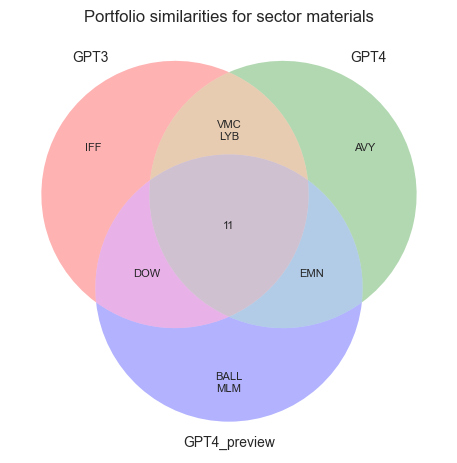

<Figure size 500x500 with 0 Axes>

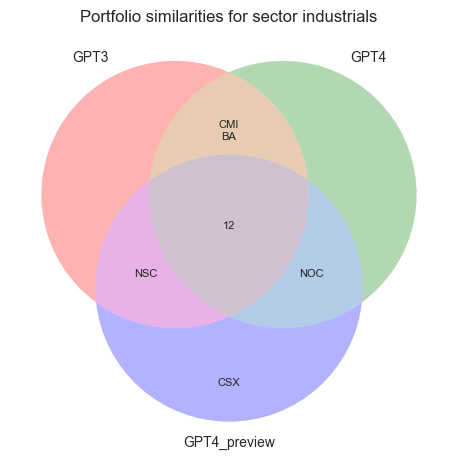

<Figure size 500x500 with 0 Axes>

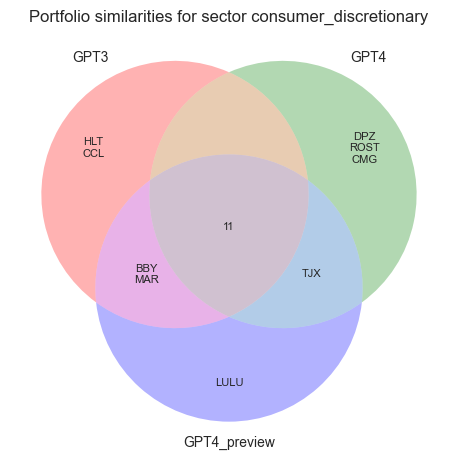

<Figure size 500x500 with 0 Axes>

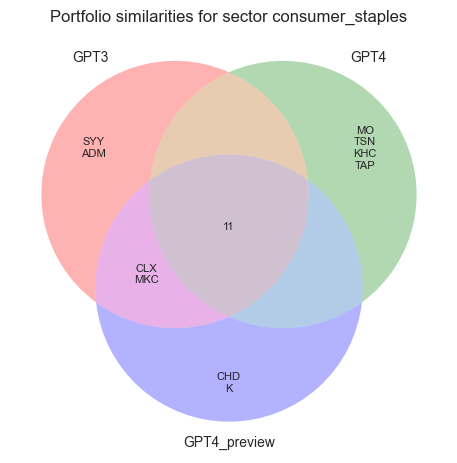

<Figure size 500x500 with 0 Axes>

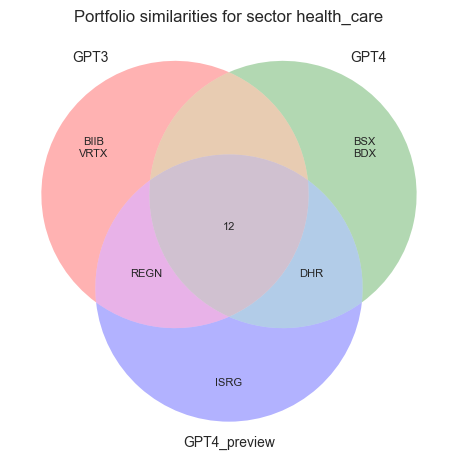

<Figure size 500x500 with 0 Axes>

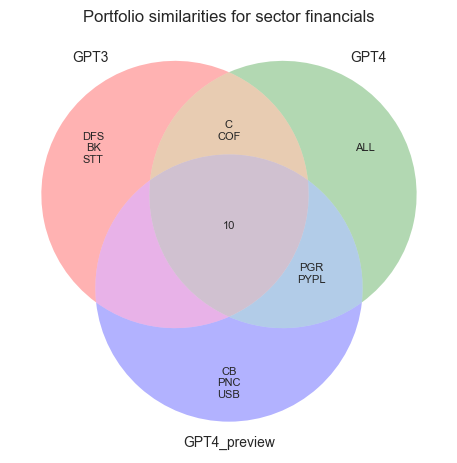

<Figure size 500x500 with 0 Axes>

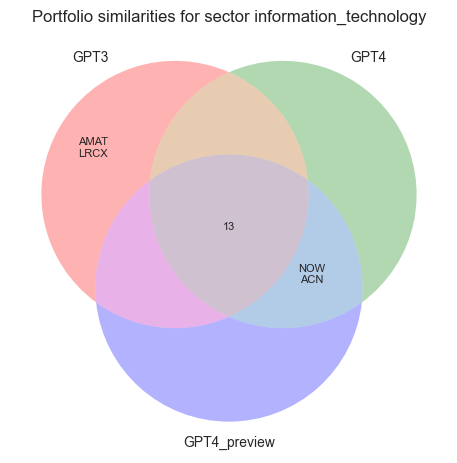

<Figure size 500x500 with 0 Axes>

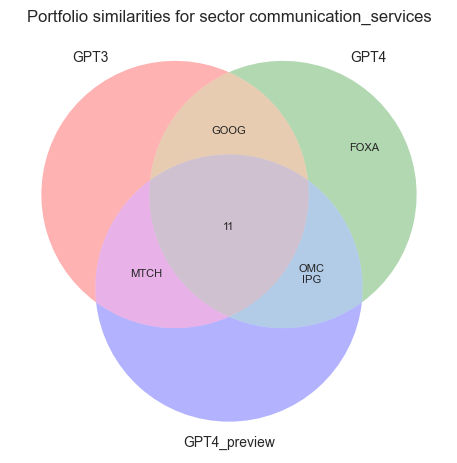

<Figure size 500x500 with 0 Axes>

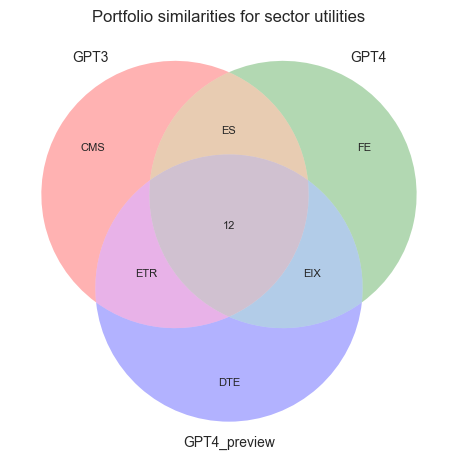

<Figure size 500x500 with 0 Axes>

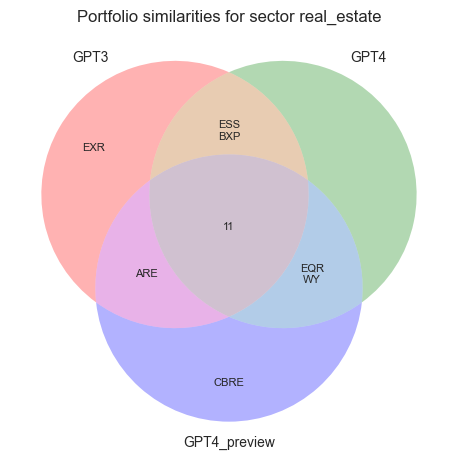

<Figure size 500x500 with 0 Axes>

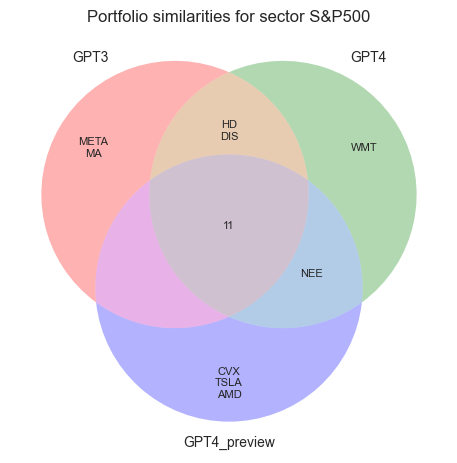

<Figure size 500x500 with 0 Axes>

In [107]:
for sector_name in sectors:
    plot_venn_with_text(sector_name)